# Phân tích và Trực quan hóa dữ liệu Laptop ASUS

Trong notebook này, chúng ta sẽ:

1. Tiền xử lý dữ liệu (Data Preprocessing)
2. Khám phá dữ liệu (Data Exploration)
3. Trực quan hóa dữ liệu với Matplotlib:
   - Line Plots (Biểu đồ đường)
   - Area Plots (Biểu đồ vùng)
   - Histograms (Biểu đồ tần suất)
   - Bar Plots (Biểu đồ cột)
   - Pie Charts (Biểu đồ tròn)
   - Box Plots (Biểu đồ hộp)
   - Scatter Plots (Biểu đồ phân tán)
   - Bubble Plots (Biểu đồ bong bóng)

In [16]:
import numpy as np
import pandas as pd
import re
import matplotlib as mpl
import matplotlib.pyplot as plt

# Thiết lập hiển thị inline cho matplotlib
%matplotlib inline

# Áp dụng style cho matplotlib
mpl.style.use('ggplot')

# Kiểm tra phiên bản matplotlib
print('Matplotlib version: ', mpl.__version__)

Matplotlib version:  3.10.6


## Import thư viện cần thiết

Chúng ta sẽ sử dụng các thư viện sau:
- **pandas**: Xử lý và phân tích dữ liệu
- **numpy**: Tính toán số học
- **matplotlib**: Trực quan hóa dữ liệu
- **re**: Xử lý biểu thức chính quy (regular expressions)

In [17]:
laptop_data = pd.read_csv("laptops_asus_data_cellphones_full_v2.csv")

## Đọc dữ liệu

Chúng ta sẽ đọc dữ liệu laptop ASUS từ file CSV và hiển thị thông tin cơ bản về dataset.

In [18]:
laptop_data.head()

,Name,Price,CPU,RAM,GPU,Storage,Screen Size,Screen Resolution,Panel,Screen frequency,Weight,URL
0,Laptop ASUS TUF Gaming F16 FX607VJ-RL034W,20.990.000đ,"Intel Core 5 210H 2.2 GHz (12MB Cache, up to 4...",16GB,NVIDIA GeForce RTX 3050 6GB GDDR6Intel Iris Xe...,512GB PCIe 4.0 NVMe M.2 SSD (2 Khe cắm M.2 hỗ ...,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-tuf-gami...
1,Laptop ASUS VivoBook Go 14 E1404FA-NK177W,11.490.000đ,"AMD Ryzen 5 7520U (4MB cache, up to 4.3 GHz, 4...",16GB,AMD Radeon Graphics,SSD 512GB M.2 NVMe PCIe 3.0,14 inches,1920 x 1080 pixels (FullHD),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...
2,Laptop ASUS Gaming Vivobook 16X K3605VC-RP431W,17.990.000đ,"Intel Core i5-13420H 2.1 GHz (12MB Cache, up t...",16GB,NVIDIA Geforce RTX 3050 4GB GDDR6 Intel UHD Gr...,512GB M.2 NVMe PCIe 4.0 SSD,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...
3,Laptop ASUS Gaming V16 V3607VU-RP343W,23.990.000đ,"Intel Core 5 210H 2.2 GHz (12MB Cache, up to 4...",16GB,NVIDIA GeForce RTX 4050 6GB GDDR6 (194 AI TOPs...,512GB M.2 NVMe PCIe 4.0 SSD,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-gaming-v...
4,Laptop ASUS Vivobook 15 X1502VA-BQ885W,13.990.000đ,"Intel Core i5-13420H 2.1 GHz (12MB Cache, up t...",16GB,Intel HD Graphics,512GB M.2 NVMe PCIe 4.0 SSD,15.6 inches,1920 x 1080 pixels (FullHD),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...


### Xem 5 dòng đầu tiên của dữ liệu

Sử dụng phương thức `head()` để xem cấu trúc và nội dung của dataset.

In [19]:
laptop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               790 non-null    object 
 1   Price              790 non-null    object 
 2   CPU                776 non-null    object 
 3   RAM                657 non-null    object 
 4   GPU                772 non-null    object 
 5   Storage            762 non-null    object 
 6   Screen Size        775 non-null    object 
 7   Screen Resolution  766 non-null    object 
 8   Panel              0 non-null      float64
 9   Screen frequency   0 non-null      float64
 10  Weight             0 non-null      float64
 11  URL                790 non-null    object 
dtypes: float64(3), object(9)
memory usage: 74.2+ KB


### Thông tin về dataset

Phương thức `info()` cho biết:
- Số lượng dòng và cột
- Kiểu dữ liệu của từng cột
- Số lượng giá trị non-null
- Bộ nhớ sử dụng

## Preprocessing Data


In [20]:
laptop_data['Price_VND'] = (
    laptop_data['Price']
    .astype(str)
    .str.replace('đ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
laptop_data['Price_VND'] = pd.to_numeric(laptop_data['Price_VND'], errors='coerce')

In [21]:
laptop_data['RAM_GB'] = (
    laptop_data['RAM']
    .astype(str)
    .str.replace('GB', '', regex=False)
    .str.strip()
)
laptop_data['RAM_GB'] = pd.to_numeric(laptop_data['RAM_GB'], errors='coerce').astype('Int64')

In [22]:
def clean_storage(storage_str):
    """
    Hàm chuyển đổi dữ liệu Storage từ string sang GB (số)
    - TB sẽ được chuyển sang GB (1 TB = 1024 GB)
    - GB giữ nguyên
    - Các giá trị không hợp lệ trả về NaN
    """
    if pd.isna(storage_str) or storage_str.upper() == 'NAN':
        return np.nan
    storage_str = storage_str.upper()
    tb_match = re.search(r'(\d+)\s*TB', storage_str)
    if tb_match:
        return float(tb_match.group(1)) * 1024
    gb_match = re.search(r'(\d+)\s*GB', storage_str)
    if gb_match:
        return float(gb_match.group(1))
    return np.nan

laptop_data['Storage_GB'] = laptop_data['Storage'].astype(str).apply(clean_storage)

### Xem dữ liệu sau khi tiền xử lý

Kiểm tra dữ liệu sau khi đã xử lý các cột Price, RAM và Storage.

In [23]:
laptop_data[['Name', 'Price_VND', 'RAM_GB', 'Storage_GB']].head(10)

,Name,Price_VND,RAM_GB,Storage_GB
0,Laptop ASUS TUF Gaming F16 FX607VJ-RL034W,20990000.0,16,2048.0
1,Laptop ASUS VivoBook Go 14 E1404FA-NK177W,11490000.0,16,512.0
2,Laptop ASUS Gaming Vivobook 16X K3605VC-RP431W,17990000.0,16,512.0
3,Laptop ASUS Gaming V16 V3607VU-RP343W,23990000.0,16,512.0
4,Laptop ASUS Vivobook 15 X1502VA-BQ885W,13990000.0,16,512.0
5,Laptop ASUS TUF Gaming F16 FX607VU-RL045W,25490000.0,16,2048.0
6,Laptop ASUS TUF Gaming A15 FA506NCR-HN097W,18990000.0,16,1024.0
7,Laptop ASUS Gaming V16 V3607VM-RP044W,34490000.0,32,1024.0
8,Laptop ASUS Vivobook Go 15 E1504GA-BQ1141W,8790000.0,8,NaN
9,Laptop ASUS Vivobook 15 OLED A1505VA-L1688W,18490000.0,16,512.0


### Thống kê mô tả

Sử dụng `describe()` để xem các thống kê cơ bản: mean, std, min, max, quartiles.

In [24]:
laptop_data[['Price_VND', 'RAM_GB', 'Storage_GB']].describe()

,Price_VND,RAM_GB,Storage_GB
count,6.370000e+02,657.0,753.000000
mean,2.684135e+07,15.427702,714.284197
std,1.813636e+07,11.383076,423.638908
min,4.490000e+06,4.0,128.000000
25%,1.609000e+07,8.0,512.000000
50%,2.199000e+07,16.0,512.000000
75%,2.999000e+07,16.0,1024.000000
max,1.459900e+08,128.0,2048.000000


---
# Trực quan hóa dữ liệu với Matplotlib

## 1. Histogram - Biểu đồ tần suất

Histogram là một cách để biểu diễn phân phối tần suất của dữ liệu số. Nó chia trục x thành các bins (khoảng), gán mỗi điểm dữ liệu vào một bin, và đếm số lượng điểm dữ liệu trong mỗi bin.

### 1.1 Histogram của giá laptop

Hãy xem phân phối giá của các laptop ASUS.

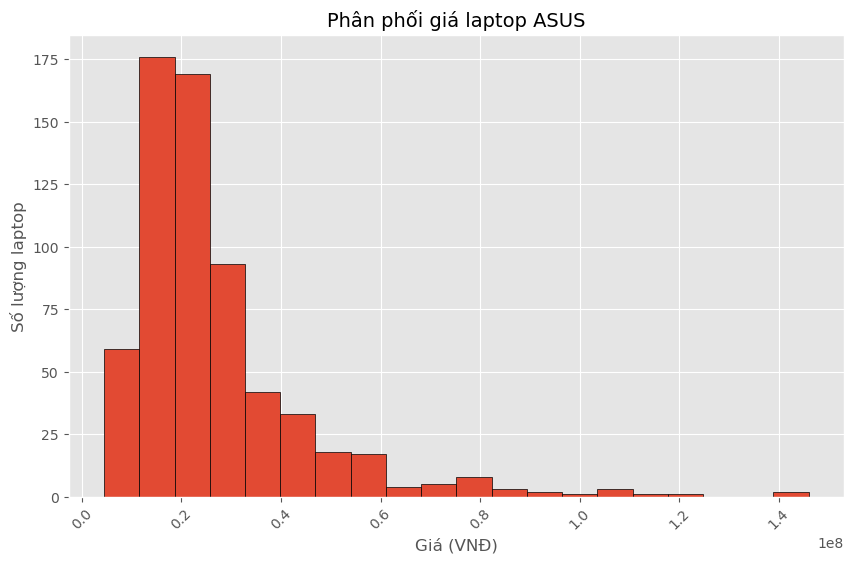

In [25]:
# Loại bỏ các giá trị NaN trước khi plot
price_data = laptop_data['Price_VND'].dropna()

# Tạo histogram với 20 bins
count, bin_edges = np.histogram(price_data, bins=20)

price_data.plot(kind='hist', bins=20, figsize=(10, 6), edgecolor='black')

plt.title('Phân phối giá laptop ASUS', fontsize=14)
plt.xlabel('Giá (VNĐ)', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)
plt.xticks(rotation=45)

plt.show()

### 1.2 Histogram của RAM

So sánh phân phối dung lượng RAM của các laptop.

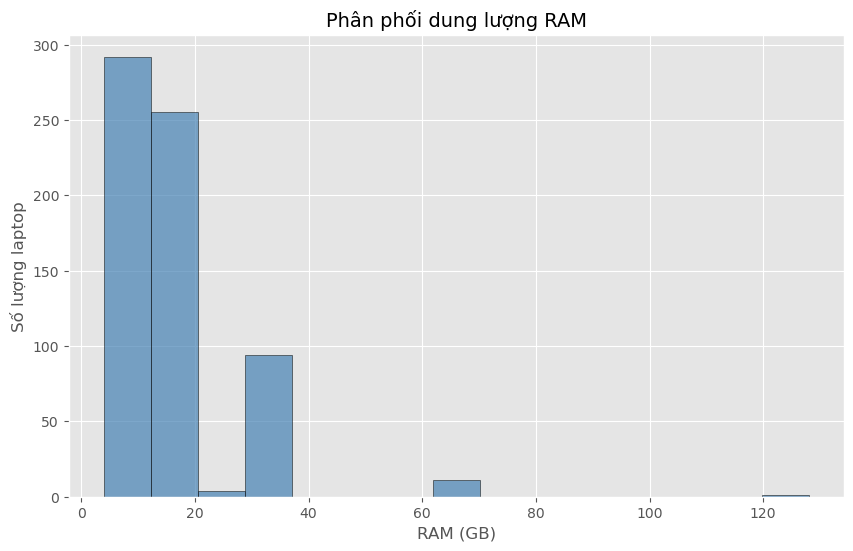

In [26]:
ram_data = laptop_data['RAM_GB'].dropna()

ram_data.plot(kind='hist', bins=15, figsize=(10, 6), 
              color='steelblue', edgecolor='black', alpha=0.7)

plt.title('Phân phối dung lượng RAM', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)

plt.show()

### 1.3 Histogram của Storage

Xem phân phối dung lượng lưu trữ.

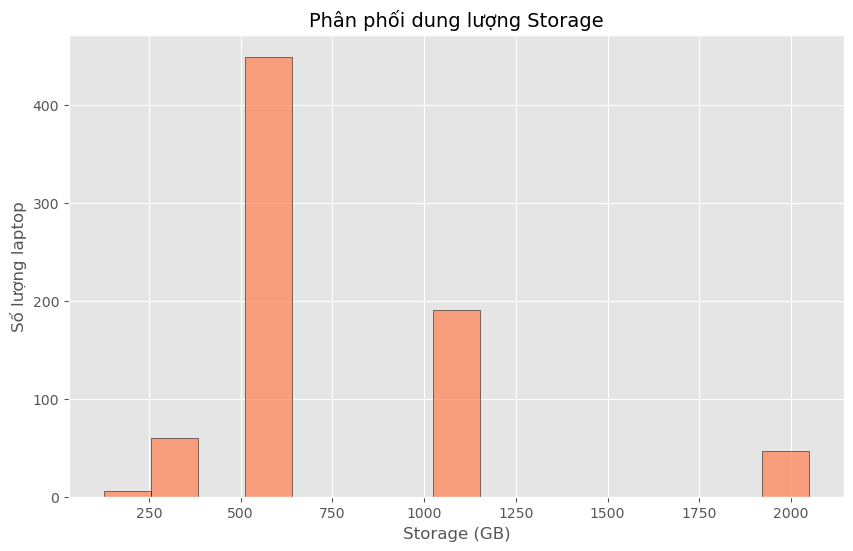

In [27]:
storage_data = laptop_data['Storage_GB'].dropna()

storage_data.plot(kind='hist', bins=15, figsize=(10, 6), 
                  color='coral', edgecolor='black', alpha=0.7)

plt.title('Phân phối dung lượng Storage', fontsize=14)
plt.xlabel('Storage (GB)', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)

plt.show()

## 2. Bar Plot - Biểu đồ cột

Bar plot được sử dụng để so sánh các giá trị giữa các danh mục khác nhau. Độ dài của cột thể hiện độ lớn của giá trị.

### 2.1 Top 10 laptop đắt nhất

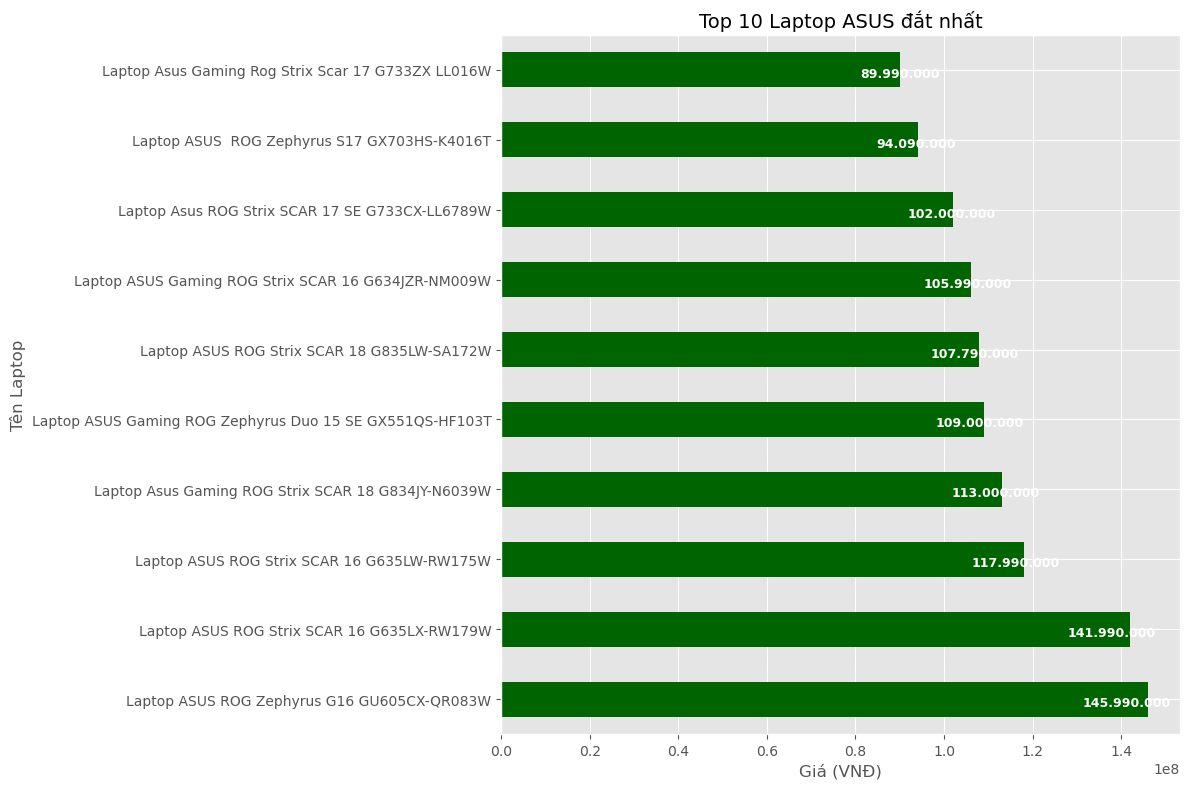

In [28]:
# Lấy top 10 laptop đắt nhất
top10_expensive = laptop_data.nlargest(10, 'Price_VND')[['Name', 'Price_VND']].copy()
top10_expensive.set_index('Name', inplace=True)

# Vẽ biểu đồ cột ngang
top10_expensive.plot(kind='barh', figsize=(12, 8), color='darkgreen', legend=False)

plt.title('Top 10 Laptop ASUS đắt nhất', fontsize=14)
plt.xlabel('Giá (VNĐ)', fontsize=12)
plt.ylabel('Tên Laptop', fontsize=12)

# Thêm nhãn giá trị
for index, value in enumerate(top10_expensive['Price_VND']):
    label = f'{int(value):,}'.replace(',', '.')
    plt.annotate(label, xy=(value - value*0.1, index - 0.1), 
                 color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Số lượng laptop theo dung lượng RAM

Biểu đồ cột đứng hiển thị số lượng laptop cho mỗi mức RAM.

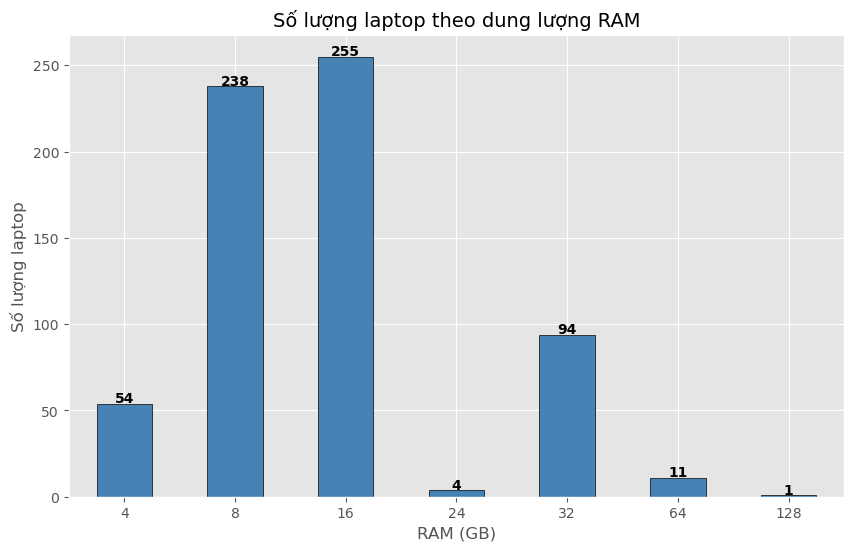

In [29]:
# Đếm số lượng laptop theo RAM
ram_counts = laptop_data['RAM_GB'].value_counts().sort_index()

ram_counts.plot(kind='bar', figsize=(10, 6), color='steelblue', edgecolor='black')

plt.title('Số lượng laptop theo dung lượng RAM', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)
plt.xticks(rotation=0)

# Thêm số lượng lên trên mỗi cột
for i, v in enumerate(ram_counts):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

## 3. Pie Chart - Biểu đồ tròn

Pie chart hiển thị tỷ lệ phần trăm của các phần trong tổng thể. Mỗi phần được biểu diễn bằng một miếng của hình tròn.

### 3.1 Tỷ lệ laptop theo dung lượng RAM

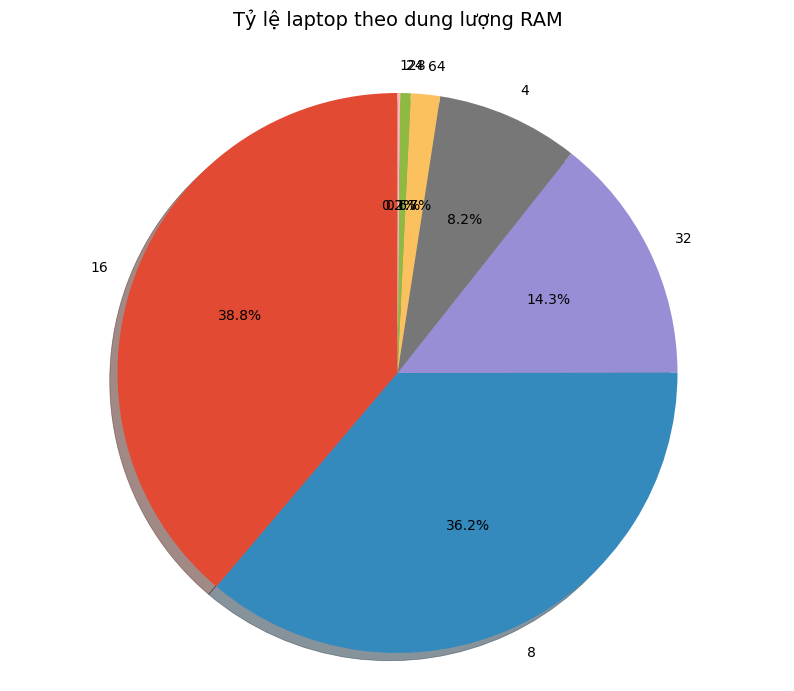

In [30]:
ram_counts = laptop_data['RAM_GB'].value_counts()

ram_counts.plot(kind='pie', 
                figsize=(10, 8),
                autopct='%1.1f%%',
                startangle=90,
                shadow=True)

plt.title('Tỷ lệ laptop theo dung lượng RAM', fontsize=14, y=1.05)
plt.ylabel('')  # Ẩn label trục y
plt.axis('equal')

plt.show()

## 4. Box Plot - Biểu đồ hộp

Box plot biểu diễn phân phối dữ liệu thông qua 5 thành phần chính:
- **Minimum**: Giá trị nhỏ nhất (không tính outliers)
- **Q1 (25%)**: Phân vị thứ nhất
- **Q2 (50% - Median)**: Trung vị
- **Q3 (75%)**: Phân vị thứ ba
- **Maximum**: Giá trị lớn nhất (không tính outliers)

Outliers là những điểm dữ liệu nằm ngoài khoảng Q1 - 1.5×IQR đến Q3 + 1.5×IQR.

### 4.1 Box plot của giá laptop

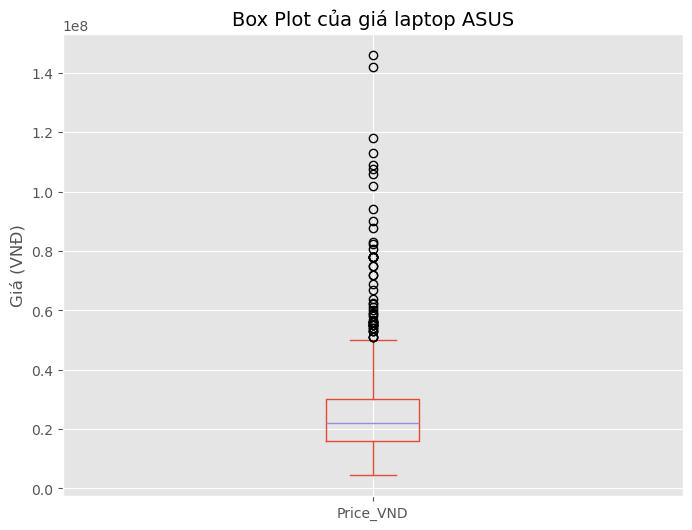

In [31]:
laptop_data[['Price_VND']].plot(kind='box', figsize=(8, 6))

plt.title('Box Plot của giá laptop ASUS', fontsize=14)
plt.ylabel('Giá (VNĐ)', fontsize=12)

plt.show()

### 4.2 So sánh Box plot của RAM và Storage

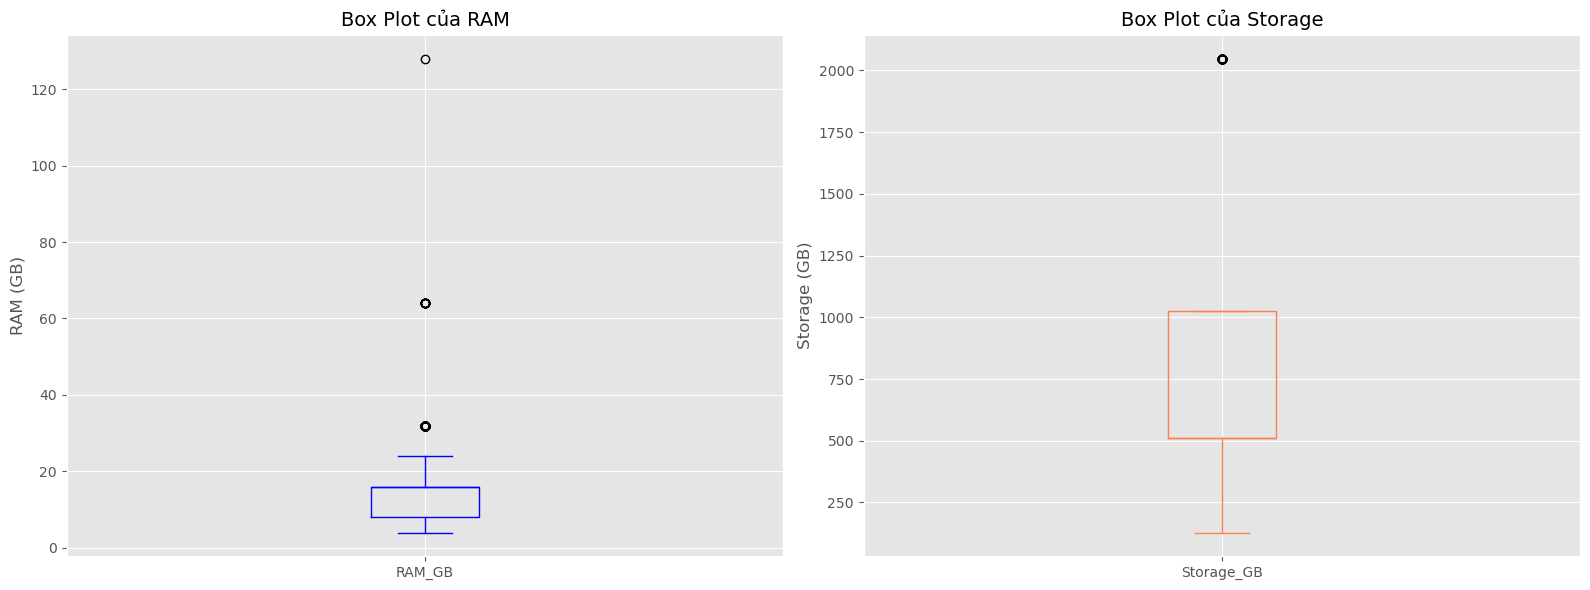

In [32]:
# So sánh RAM và Storage với subplots
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Box plot của RAM
ax0 = fig.add_subplot(1, 2, 1)
laptop_data[['RAM_GB']].plot(kind='box', ax=ax0, color='blue')
ax0.set_title('Box Plot của RAM', fontsize=14)
ax0.set_ylabel('RAM (GB)', fontsize=12)

# Subplot 2: Box plot của Storage
ax1 = fig.add_subplot(1, 2, 2)
laptop_data[['Storage_GB']].plot(kind='box', ax=ax1, color='coral')
ax1.set_title('Box Plot của Storage', fontsize=14)
ax1.set_ylabel('Storage (GB)', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Scatter Plot - Biểu đồ phân tán

Scatter plot hiển thị mối quan hệ giữa hai biến số. Mỗi điểm đại diện cho một quan sát với giá trị trên trục x và y.

### 5.1 Mối quan hệ giữa RAM và Giá

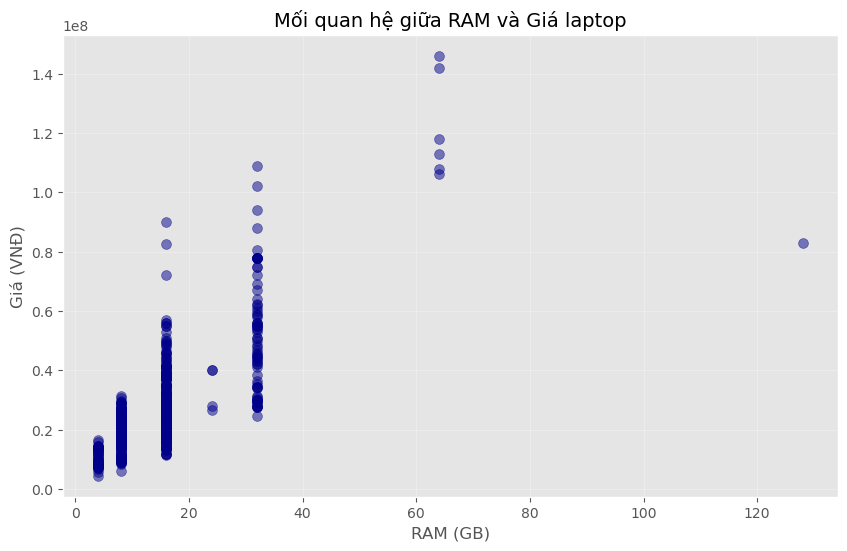

In [33]:
# Lọc dữ liệu không có giá trị NaN
df_scatter = laptop_data[['RAM_GB', 'Price_VND']].dropna()

df_scatter.plot(kind='scatter', x='RAM_GB', y='Price_VND', 
                figsize=(10, 6), color='darkblue', alpha=0.5, s=50)

plt.title('Mối quan hệ giữa RAM và Giá laptop', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### 5.2 Mối quan hệ giữa Storage và Giá

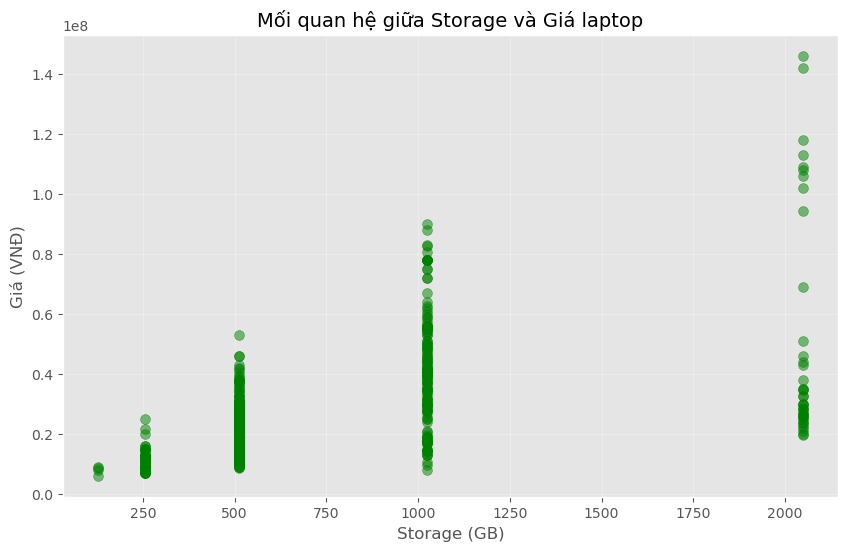

In [34]:
df_scatter2 = laptop_data[['Storage_GB', 'Price_VND']].dropna()

df_scatter2.plot(kind='scatter', x='Storage_GB', y='Price_VND', 
                 figsize=(10, 6), color='green', alpha=0.5, s=50)

plt.title('Mối quan hệ giữa Storage và Giá laptop', fontsize=14)
plt.xlabel('Storage (GB)', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

### 5.3 Scatter plot với đường hồi quy tuyến tính (Line of Best Fit)

Chúng ta có thể thêm đường hồi quy để xem xu hướng tổng quát của dữ liệu.

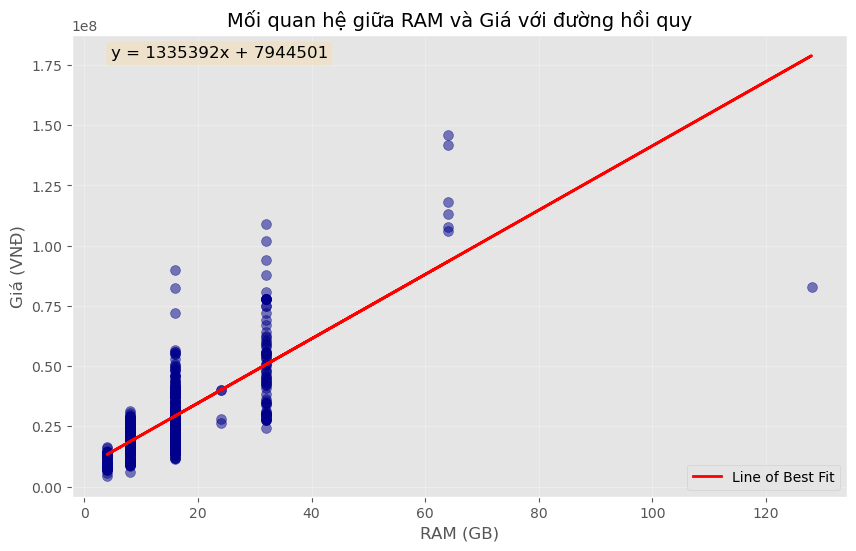

In [35]:
df_scatter = laptop_data[['RAM_GB', 'Price_VND']].dropna()

# Tính toán đường hồi quy tuyến tính
x = df_scatter['RAM_GB']
y = df_scatter['Price_VND']
fit = np.polyfit(x, y, deg=1)

# Vẽ scatter plot
df_scatter.plot(kind='scatter', x='RAM_GB', y='Price_VND', 
                figsize=(10, 6), color='darkblue', alpha=0.5, s=50)

# Vẽ đường hồi quy
plt.plot(x, fit[0] * x + fit[1], color='red', linewidth=2, label='Line of Best Fit')

plt.title('Mối quan hệ giữa RAM và Giá với đường hồi quy', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Hiển thị phương trình đường hồi quy
equation = f'y = {fit[0]:.0f}x + {fit[1]:.0f}'
plt.annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

## 6. Bubble Plot - Biểu đồ bong bóng

Bubble plot là biến thể của scatter plot hiển thị 3 chiều dữ liệu (x, y, z). Kích thước của bong bóng được xác định bởi biến thứ 3 (z).

### 6.1 So sánh RAM, Storage và Giá

Kích thước bong bóng đại diện cho dung lượng Storage.

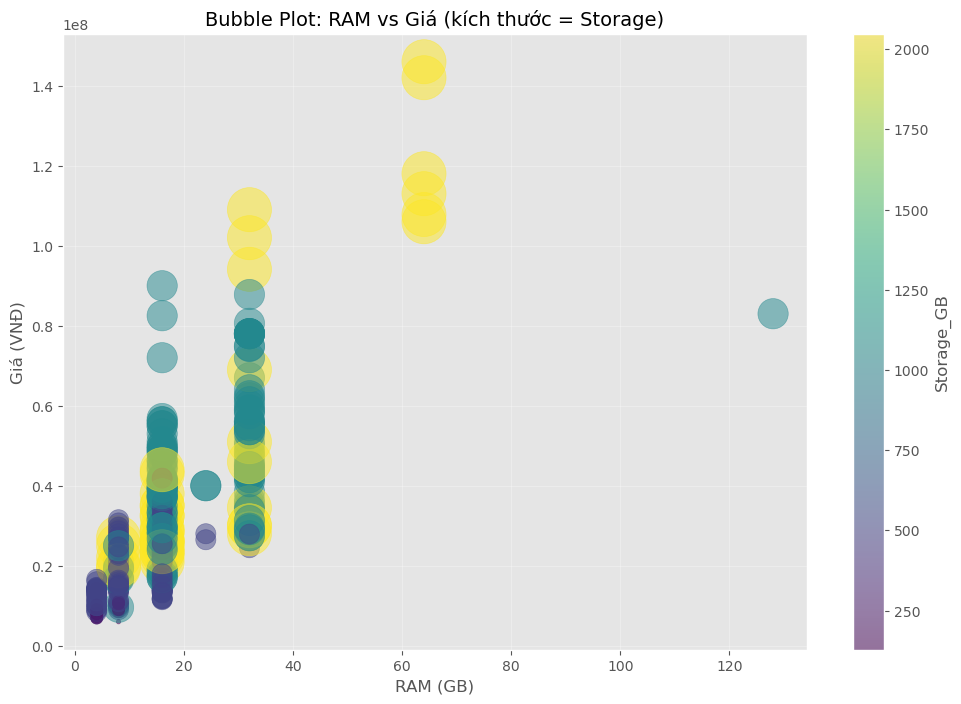

In [36]:
# Chuẩn bị dữ liệu
df_bubble = laptop_data[['RAM_GB', 'Price_VND', 'Storage_GB']].dropna()

# Chuẩn hóa Storage để làm kích thước bong bóng
norm_storage = (df_bubble['Storage_GB'] - df_bubble['Storage_GB'].min()) / \
               (df_bubble['Storage_GB'].max() - df_bubble['Storage_GB'].min())

# Vẽ bubble plot
df_bubble.plot(kind='scatter', 
               x='RAM_GB', 
               y='Price_VND',
               s=norm_storage * 1000 + 10,  # Kích thước bong bóng
               alpha=0.5,
               figsize=(12, 8),
               c='Storage_GB',  # Màu theo Storage
               cmap='viridis',  # Bảng màu
               colorbar=True)

plt.title('Bubble Plot: RAM vs Giá (kích thước = Storage)', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Giá (VNĐ)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## 7. Line Plot - Biểu đồ đường

Line plot thích hợp để hiển thị xu hướng theo thời gian hoặc so sánh các nhóm liên tục.

### 7.1 Giá trung bình theo dung lượng RAM

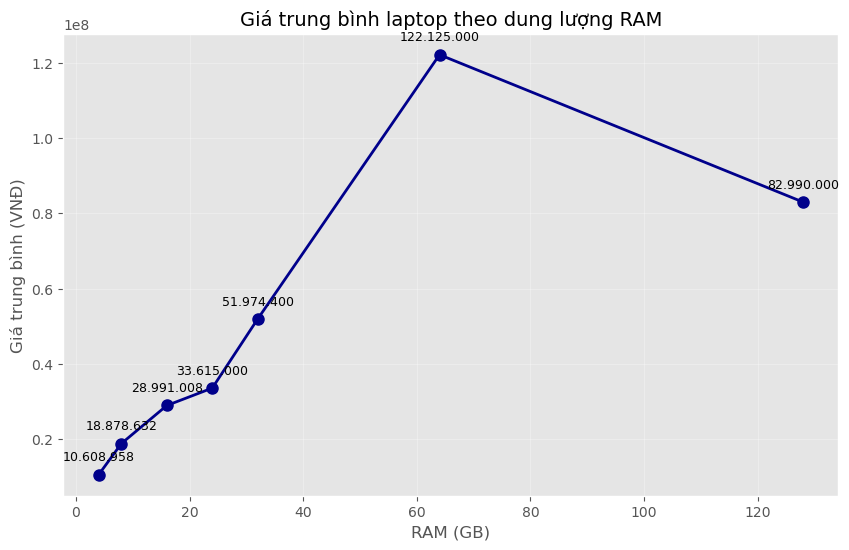

In [37]:
# Tính giá trung bình theo RAM
avg_price_by_ram = laptop_data.groupby('RAM_GB')['Price_VND'].mean().sort_index()

avg_price_by_ram.plot(kind='line', figsize=(10, 6), marker='o', 
                      color='darkblue', linewidth=2, markersize=8)

plt.title('Giá trung bình laptop theo dung lượng RAM', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Giá trung bình (VNĐ)', fontsize=12)
plt.grid(True, alpha=0.3)

# Thêm giá trị lên mỗi điểm
for x, y in zip(avg_price_by_ram.index, avg_price_by_ram.values):
    plt.annotate(f'{int(y):,}'.replace(',', '.'), 
                 xy=(x, y), 
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9)

plt.show()

## 8. Area Plot - Biểu đồ vùng

Area plot tương tự line plot nhưng vùng dưới đường được tô màu.

### 8.1 So sánh số lượng laptop theo RAM với Area Plot

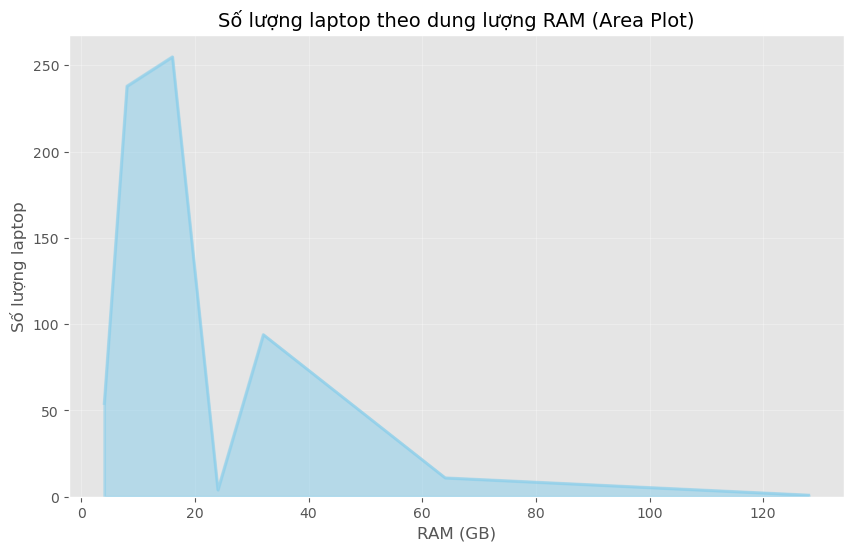

In [38]:
# Đếm số lượng theo RAM
ram_counts_sorted = laptop_data['RAM_GB'].value_counts().sort_index()

ram_counts_sorted.plot(kind='area', figsize=(10, 6), 
                       alpha=0.5, color='skyblue', linewidth=2)

plt.title('Số lượng laptop theo dung lượng RAM (Area Plot)', fontsize=14)
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

## 9. Kết hợp nhiều biểu đồ - Subplots

Chúng ta có thể kết hợp nhiều biểu đồ trong một figure để so sánh dễ dàng hơn.

### 9.1 Tổng quan về phân phối dữ liệu

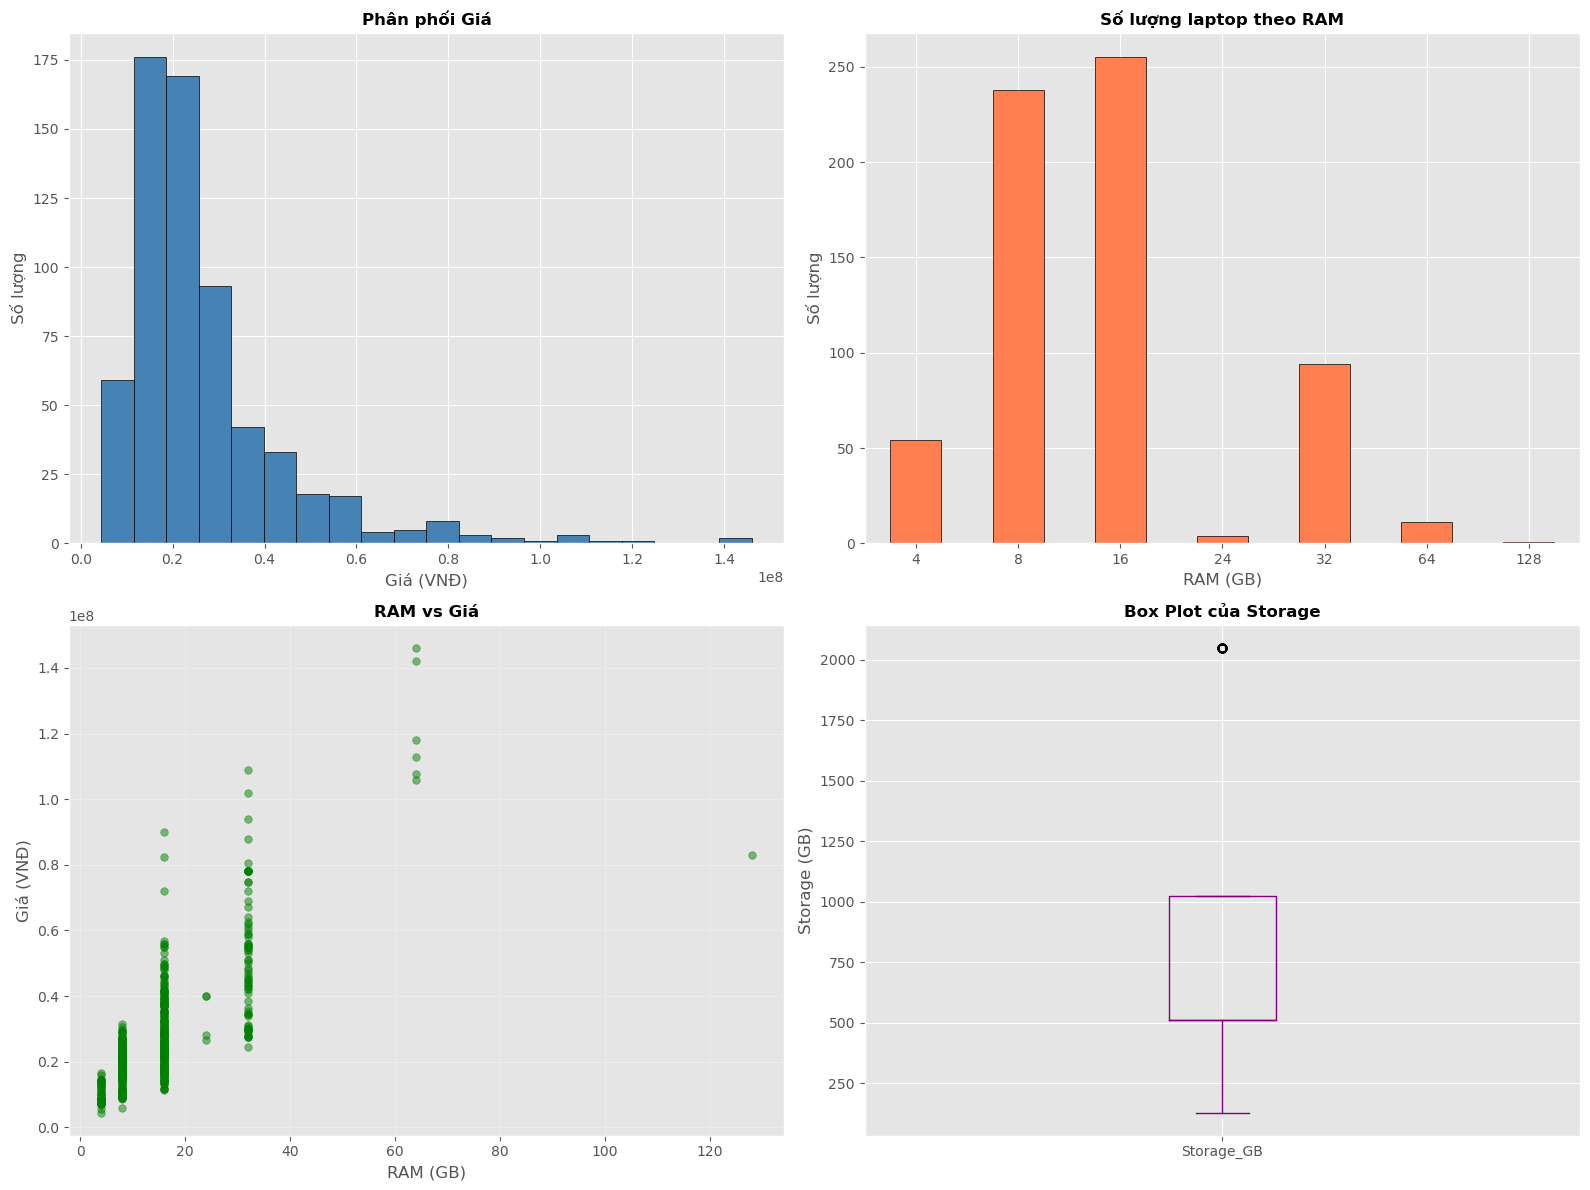

In [39]:
fig = plt.figure(figsize=(16, 12))

# Subplot 1: Histogram của Giá
ax1 = fig.add_subplot(2, 2, 1)
laptop_data['Price_VND'].dropna().plot(kind='hist', bins=20, ax=ax1, 
                                        color='steelblue', edgecolor='black')
ax1.set_title('Phân phối Giá', fontsize=12, fontweight='bold')
ax1.set_xlabel('Giá (VNĐ)')
ax1.set_ylabel('Số lượng')

# Subplot 2: Bar plot - Số lượng theo RAM
ax2 = fig.add_subplot(2, 2, 2)
ram_counts = laptop_data['RAM_GB'].value_counts().sort_index()
ram_counts.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Số lượng laptop theo RAM', fontsize=12, fontweight='bold')
ax2.set_xlabel('RAM (GB)')
ax2.set_ylabel('Số lượng')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Subplot 3: Scatter plot - RAM vs Giá
ax3 = fig.add_subplot(2, 2, 3)
df_scatter = laptop_data[['RAM_GB', 'Price_VND']].dropna()
df_scatter.plot(kind='scatter', x='RAM_GB', y='Price_VND', 
                ax=ax3, color='green', alpha=0.5, s=30)
ax3.set_title('RAM vs Giá', fontsize=12, fontweight='bold')
ax3.set_xlabel('RAM (GB)')
ax3.set_ylabel('Giá (VNĐ)')
ax3.grid(True, alpha=0.3)

# Subplot 4: Box plot của Storage
ax4 = fig.add_subplot(2, 2, 4)
laptop_data[['Storage_GB']].plot(kind='box', ax=ax4, color='purple')
ax4.set_title('Box Plot của Storage', fontsize=12, fontweight='bold')
ax4.set_ylabel('Storage (GB)')

plt.tight_layout()
plt.show()

## 10. Kết luận

Trong notebook này, chúng ta đã:

1. **Tiền xử lý dữ liệu**: Làm sạch và chuyển đổi dữ liệu Price, RAM và Storage sang định dạng số phù hợp để phân tích.

2. **Khám phá dữ liệu**: Sử dụng `head()`, `info()`, `describe()` để hiểu cấu trúc và đặc điểm của dataset.

3. **Trực quan hóa dữ liệu** với nhiều loại biểu đồ:
   - **Histogram**: Phân phối giá, RAM, Storage
   - **Bar Plot**: Top 10 laptop đắt nhất, số lượng theo RAM
   - **Pie Chart**: Tỷ lệ laptop theo RAM
   - **Box Plot**: Phân phối thống kê của giá, RAM, Storage
   - **Scatter Plot**: Mối quan hệ giữa RAM/Storage và giá
   - **Bubble Plot**: Hiển thị 3 chiều dữ liệu cùng lúc
   - **Line Plot**: Xu hướng giá trung bình theo RAM
   - **Area Plot**: Số lượng laptop theo RAM
   - **Subplots**: Kết hợp nhiều biểu đồ để so sánh

### Một số insights từ dữ liệu:

- Phần lớn laptop ASUS có giá trong khoảng trung bình
- RAM phổ biến nhất là 8GB và 16GB
- Có mối quan hệ tích cực giữa RAM và giá laptop
- Dung lượng Storage có sự đa dạng từ 256GB đến 1TB+
- Giá trung bình tăng theo dung lượng RAM

### Các kỹ thuật đã sử dụng:

- **Pandas**: Xử lý và phân tích dữ liệu
- **Matplotlib**: Tạo các loại biểu đồ khác nhau
- **NumPy**: Tính toán hồi quy tuyến tính
- **Regular Expression**: Xử lý và làm sạch dữ liệu text